In [2]:
import sys
import numpy as np
import anndata as ad

import polars as pl
import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
mt = ad.read_h5ad('private/data/clean_method/mutant_inferred.h5ad')

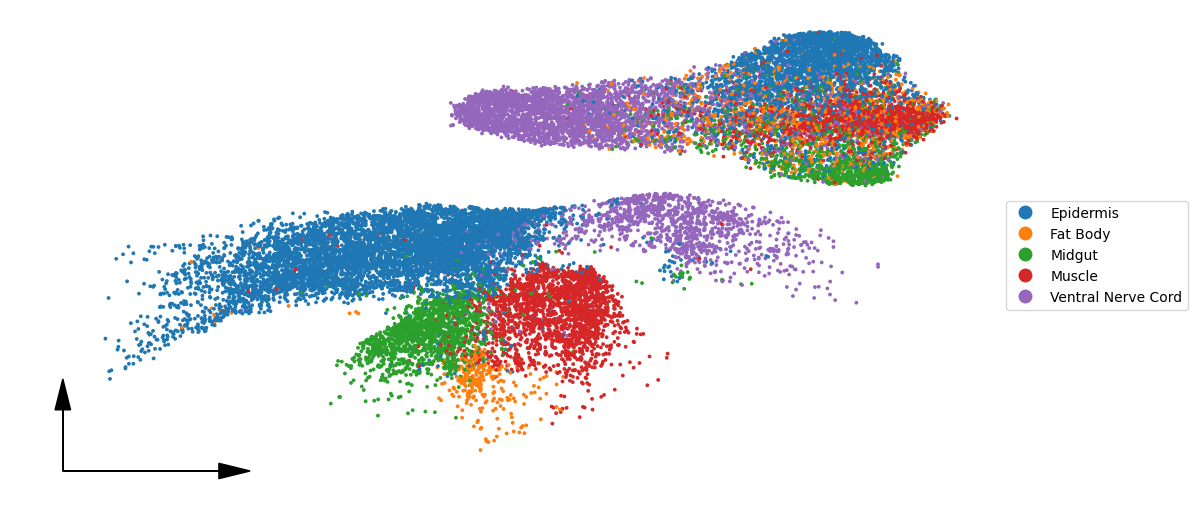

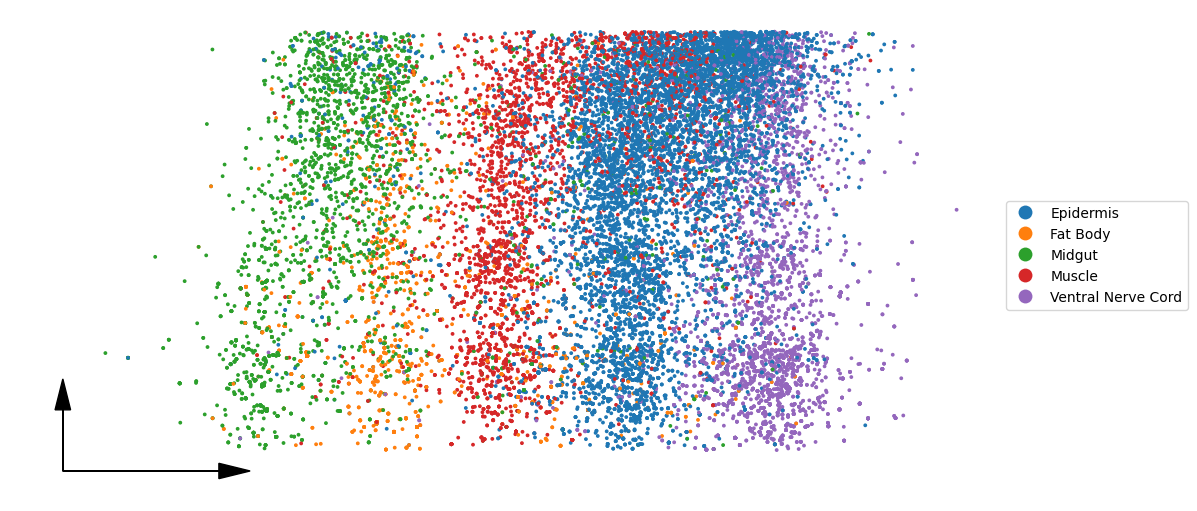

In [ ]:
scit.pl.embedding2d(mt, 'X_umap', 'label')

In [5]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
#cttag = cttag[cttag.obs['timep']=='14_16h'].copy()

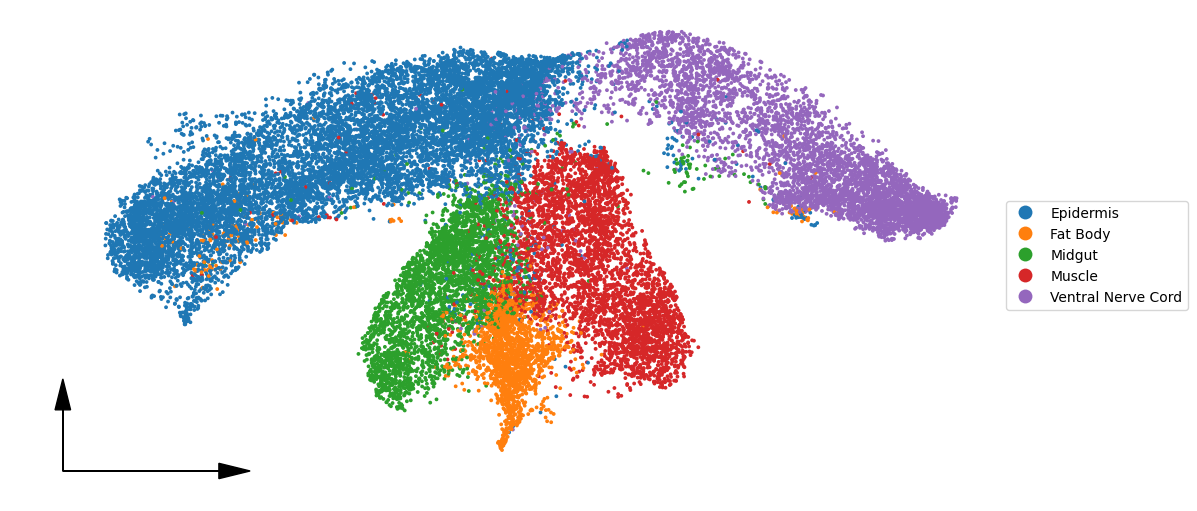

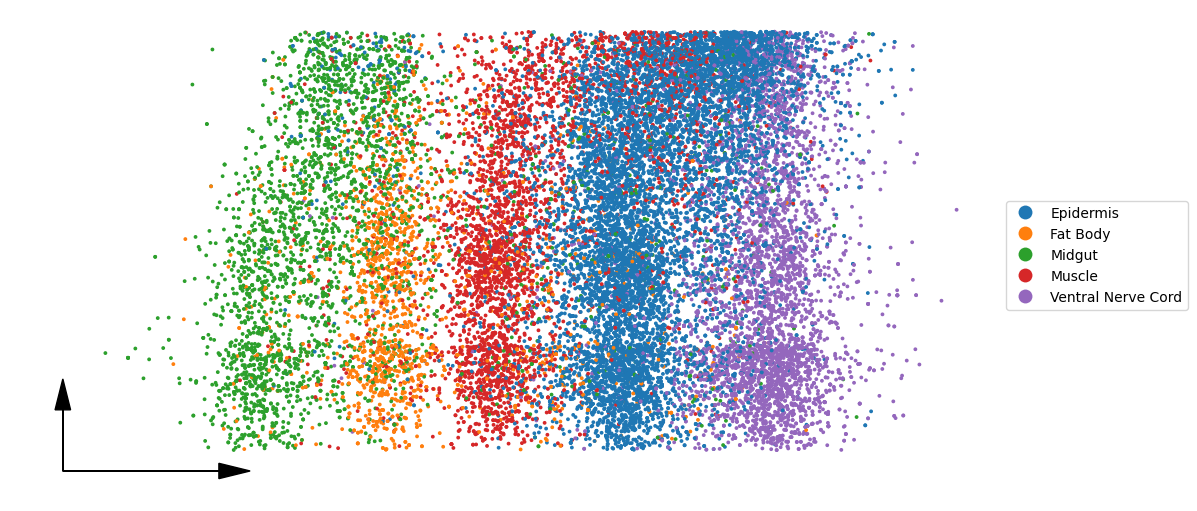

In [14]:
scit.pl.embedding2d(cttag, 'X_umap', 'label')
scit.pl.embedding2d(cttag, 'X_landscape', 'label')

In [4]:
methylation_means = pl.read_csv('private/newest/late_methylation.csv')

rna_change = pl.read_excel('private/data/snrna_difex_MAST_per_clusters_251117_all.xlsx', sheet_id=0)
rna_change.keys()

dict_keys(['Neuronal 1', 'Epidermis', 'Muscle somatic', 'Yolk', 'Midgut', 'Fat Body', 'Tracheal', 'Glia', 'Plasmatocytes', 'Muscle visceral', 'Neuronal 2', 'Salivary Gland', 'Epidermis head', 'Sense', 'Glia lateral', 'Amnioserosa', 'Bristle'])

In [5]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()
#muscle_up = pl.read_csv('private/muscle_meth_up.txt', has_header=False).to_numpy().ravel()
#muscle_down = pl.read_csv('private/muscle_meth_down.txt', has_header=False).to_numpy().ravel()

In [6]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=False,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=False,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

In [7]:
from src.tools._layers import get_layer_feature_means
acet_means = get_layer_feature_means(cttag[cttag.obs['label'] == 'Muscle'], lc_acet)
acet_means_d = dict(zip(cttag.uns['gene_names_acet'], acet_means))
pl.DataFrame(acet_means_d).transpose(include_header=True).write_csv('private/data/acet_means_muscle.csv')

meth_means = get_layer_feature_means(cttag[cttag.obs['label'] == 'Muscle'], lc_meth)
meth_means_d = dict(zip(cttag.uns['gene_names_acet'], meth_means))
pl.DataFrame(meth_means_d).transpose(include_header=True).write_csv('private/data/meth_means_muscle.csv')

In [8]:
import polars as pl
mt_muscle_meth = pl.read_csv('private/data/wt_mt_meth_change.csv').filter((pl.col('group') == 'Muscle')).with_columns(
    np.log10(pl.col('pval')).neg().alias('ppval')
)
mt_muscle_acet = pl.read_csv('private/data/wt_mt_acet_change.csv').filter((pl.col('group') == 'Muscle')).with_columns(
    np.log10(pl.col('pval')).neg().alias('ppval')
)

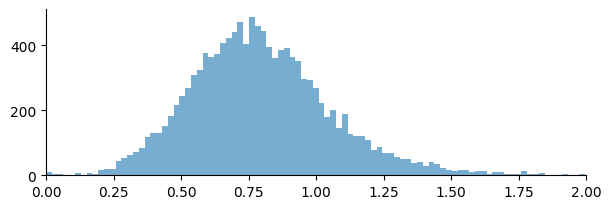

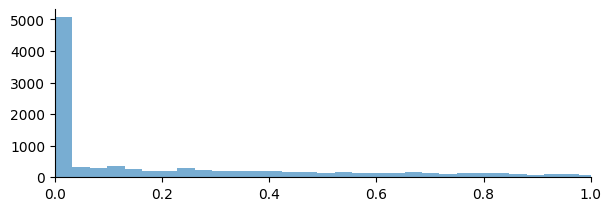

In [9]:
scit.set_defaults(figsize=(6,2))
scit.pl.int.histogram(
    [
        mt_muscle_acet['base_mean'].to_numpy(),
        #mt_muscle_acet['base_mean'].to_numpy()
    ], xminmax=(0,2), bins=200
)
scit.pl.int.histogram(
    [
        mt_muscle_acet['ppval'].to_numpy()
    ], xminmax=(0, 1), bins=200
)

In [10]:
methylated_genes = (methylation_means.filter(pl.col('Muscle') > 2))['name'].to_numpy()

#.filter(pl.col('pval')<0.5)

mt_muscle_acet = mt_muscle_acet.filter(pl.col('name').is_in(methylated_genes))
mt_muscle_acet = mt_muscle_acet.with_columns(
    #(pl.col('ppval') * pl.col('score').sign()).alias('adj_score')
    (pl.col('ppval') * pl.col('score')).alias('adj_score')
).sort('adj_score')
mt_muscle_acet

pval,score,name,base_mean,group,ppval,adj_score
f64,f64,str,f64,str,f64,f64
0.000333,-1.072432,"""snoRNA:660""",1.7190684,"""Muscle""",3.476988,-3.728831
0.008653,-1.657804,"""elB""",0.946757,"""Muscle""",2.062853,-3.419806
0.013544,-1.696484,"""salm""",0.7963973,"""Muscle""",1.868248,-3.169453
0.003883,-1.270031,"""tRNA:Gly-TCC-1-3""",0.7683022,"""Muscle""",2.410871,-3.061881
0.009308,-1.446996,"""edl""",0.83367,"""Muscle""",2.031164,-2.939086
…,…,…,…,…,…,…
0.000559,1.146442,"""fd96Cb""",1.0113397,"""Muscle""",3.25287,3.729227
0.030416,3.1858008,"""CG9380""",0.6709763,"""Muscle""",1.516894,4.832523
0.006993,2.4114895,"""CG30428""",0.912887,"""Muscle""",2.155334,5.197565


In [19]:
mtype = 'Muscle somatic'

rna_df = rna_change[mtype].with_columns(
    -np.log10(pl.col('p_val')).alias('ppval')
).with_columns(
    #(pl.col('ppval') * pl.col('score').sign()).alias('adj_score')
    (pl.col('ppval') * pl.col('avg_log2FC')).alias('adj_score')
)

mentioned = rna_df[['gene_name']].to_numpy().ravel()
muscle_up_df = rna_df.filter(pl.col('p_val') < 0.05).filter(pl.col('avg_log2FC') > 0.5)
muscle_up = muscle_up_df[['gene_name']].to_numpy().ravel()
muscle_down_df = rna_df.filter(pl.col('p_val') < 0.05).filter(pl.col('avg_log2FC') < -0.5)
muscle_down = muscle_down_df[['gene_name']].to_numpy().ravel()

/tmp/nix-shell-29596-0/ipykernel_34363/4038372154.py:3: RuntimeWarning: invalid value encountered in log1p
  scit.pl.int.scatter(np.log1p(np.c_[df['adj_score'], df['adj_score_rna']]), xlabel='acet', ylabel='rna')


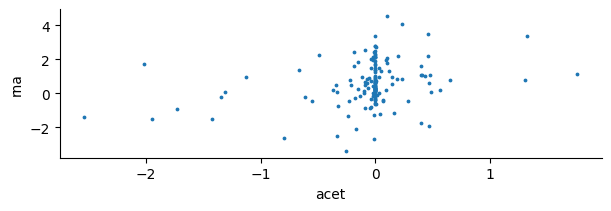

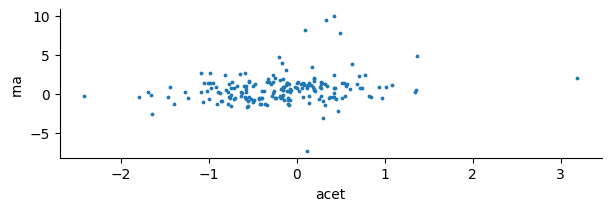

In [12]:
df = mt_muscle_acet.join(rna_df.filter(pl.col('p_val') < 0.5)
                         , left_on='name', right_on='gene_name', suffix='_rna')
scit.pl.int.scatter(np.log1p(np.c_[df['adj_score'], df['adj_score_rna']]), xlabel='acet', ylabel='rna')
scit.pl.int.scatter((np.c_[df['score'], df['avg_log2FC']]), xlabel='acet', ylabel='rna')

In [13]:
mt_muscle_acet.filter(pl.col('name') == 'srp')

pval,score,name,base_mean,group,ppval,adj_score
f64,f64,str,f64,str,f64,f64
1.0,0.093374,"""srp""",0.9336271,"""Muscle""",-0.0,-0.0


In [ ]:
# muscle_up_df = rna_change_my.filter(pl.col('group')=='Muscle somatic').filter(pl.col('pval') < 0.0001).filter(pl.col('score') > 0.5)
# muscle_up = muscle_up_df[['name']].to_numpy().ravel()
# muscle_down_df = rna_change_my.filter(pl.col('group')=='Muscle somatic').filter(pl.col('pval') < 0.0001).filter(pl.col('score') < -0.5)
# muscle_down = muscle_down_df[['name']].to_numpy().ravel()
# print(len(muscle_up))
# print(len(muscle_down))

In [18]:
mt_muscle_acet

pval,score,name,base_mean,group,ppval,adj_score
f64,f64,str,f64,str,f64,f64
0.000333,-1.072432,"""snoRNA:660""",1.7190684,"""Muscle""",3.476988,-3.728831
0.008653,-1.657804,"""elB""",0.946757,"""Muscle""",2.062853,-3.419806
0.013544,-1.696484,"""salm""",0.7963973,"""Muscle""",1.868248,-3.169453
0.003883,-1.270031,"""tRNA:Gly-TCC-1-3""",0.7683022,"""Muscle""",2.410871,-3.061881
0.009308,-1.446996,"""edl""",0.83367,"""Muscle""",2.031164,-2.939086
…,…,…,…,…,…,…
0.000559,1.146442,"""fd96Cb""",1.0113397,"""Muscle""",3.25287,3.729227
0.030416,3.1858008,"""CG9380""",0.6709763,"""Muscle""",1.516894,4.832523
0.006993,2.4114895,"""CG30428""",0.912887,"""Muscle""",2.155334,5.197565


(None,)

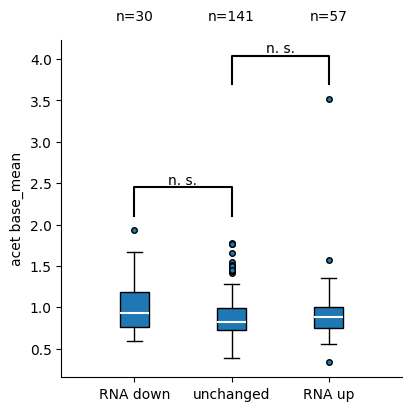

In [22]:
scit.set_defaults(figsize=(4,4))

METRIC = 'base_mean'
# scit.pl.int.boxplot(
#     [mt_muscle_meth['adj_score'].to_numpy(), 
#      mt_muscle_meth.filter(pl.col('name').is_in(muscle_up))['adj_score'].to_numpy(), 
#      mt_muscle_meth.filter(pl.col('name').is_in(muscle_down))['adj_score'].to_numpy()],
#     ['all', f'RNA up \n{mtype}', f'RNA down \n {mtype}']
# ),

allgene = mt_muscle_acet[METRIC].to_numpy()
exgene = mt_muscle_acet.filter(pl.col('name').is_in(np.union1d(muscle_up, muscle_down)).not_()).filter(pl.col('name').is_in(mentioned))[METRIC].to_numpy()
upgene = mt_muscle_acet.filter(pl.col('name').is_in(muscle_up))[METRIC].to_numpy()
downgene = mt_muscle_acet.filter(pl.col('name').is_in(muscle_down))[METRIC].to_numpy()

stat = scit.tl.statistic_test([downgene,exgene,upgene],[(0,1), (2,1)],test_type='ttest',welch=True)

s = 'log2FC' if METRIC == 'score' else 'base_mean'

scit.pl.int.boxplot(
    [downgene, exgene, upgene],
    ['RNA down', 'unchanged', 'RNA up'], stat=stat,write_n=True, ylabel=f'acet {s}', color='tab:blue', 
    show=False,
).savefig(f'private/newest/figures/acet_{s}_kd.pdf'),

In [44]:
for u in exgene:
    print(str(u))

1.7190684
0.94675714
0.7963973
0.7683022
0.88154364
0.8955499
0.7111026
0.87667084
0.6763644
0.7362685
1.4543217
0.7529826
1.3621713
0.9200727
0.93126404
0.9658611
0.66106653
0.9419426
0.72195077
0.78960395
0.6500318
0.86270374
0.6663857
0.73005366
1.2331458
0.6085199
0.6085199
0.88411903
1.1950883
1.0237116
0.989254
0.989254
0.813445
0.73683435
0.98065984
0.98065984
0.78770465
0.7839134
0.8231608
0.9516736
1.0803216
0.83728683
0.6665952
0.76945865
1.2232045
0.5626197
0.89627445
0.93700075
1.5420728
0.8178699
0.81962323
0.96267784
0.7896279
0.92166907
1.4197545
1.0266905
1.0266905
1.2775335
0.9457741
0.6940875
0.92097664
1.1691064
0.8466008
1.1639036
1.099556
1.0088227
0.5781872
0.92830676
1.0040994
0.901894
0.85301125
1.1126482
0.6123797
0.55297256
1.0942494
0.6002679
0.7130616
1.4149144
1.4149144
0.8492834
0.65702105
0.69195104
1.1089407
1.1089407
0.7971945
0.885417
1.3845057
1.1055359
0.99671334
1.5087504
0.90844405
0.5717956
0.5717956
0.769576
0.7021265
0.7021265
0.91764534
0.44941

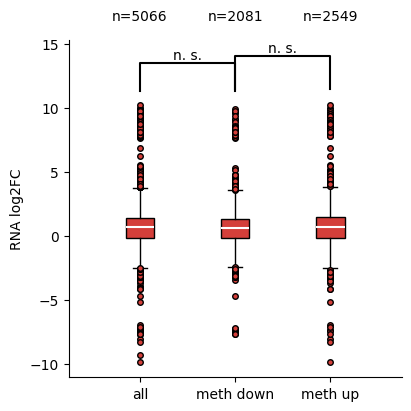

(None,)

In [17]:
scit.set_defaults(figsize=(4,4))

METRIC = 'avg_log2FC'

muscle_meth_up = mt_muscle_meth.filter(pl.col('score') > 0)['name'].to_numpy()
muscle_meth_down = mt_muscle_meth.filter(pl.col('score') < 0)['name'].to_numpy()
rna_df = rna_change[mtype]

allgene = rna_df[METRIC].to_numpy()
upgene = rna_df.filter(pl.col('gene_name').is_in(muscle_meth_up))[METRIC].to_numpy()
downgene = rna_df.filter(pl.col('gene_name').is_in(muscle_meth_down))[METRIC].to_numpy()

stat = scit.tl.statistic_test([allgene,downgene,upgene],[(0,1), (2,1)],test_type='ttest')

scit.pl.int.boxplot(
    [allgene, 
     downgene, upgene], 
    ['all', f'meth down', 'meth up'], stat=stat, write_n=True, ylabel='RNA log2FC'
),

In [85]:
mt_muscle_meth.filter(pl.col('score') > 0)

pval,score,name,base_mean,group,ppval,adj_score
f64,f64,str,f64,str,f64,f64
0.455551,0.2566851,"""gcm2""",8.776939,"""Muscle""",0.341463,0.087648
0.4258147,0.256705,"""CG3650""",3.0471673,"""Muscle""",0.370779,0.095181
0.483216,0.3424677,"""en""",14.616566,"""Muscle""",0.315858,0.108171
0.4689634,0.358049,"""Dll""",9.658158,"""Muscle""",0.328861,0.117748
0.4835811,0.417023,"""H2.0""",4.6032357,"""Muscle""",0.315531,0.131583
…,…,…,…,…,…,…
0.157819,0.7373233,"""AANATL2""",3.2661767,"""Muscle""",0.80184,0.591215
0.190906,0.8529994,"""Oat""",1.9735034,"""Muscle""",0.719181,0.613461
0.091038,0.594133,"""tRNA:Gly-TCC-1-3""",2.4923785,"""Muscle""",1.040778,0.618361


In [99]:
meth_up = mt_muscle_meth.filter(pl.col('score') > 0.5)['name'].to_numpy()
meth_down = mt_muscle_meth.filter(pl.col('score') < -0.5)['name'].to_numpy()

In [147]:
rna_change_my = pl.read_csv('private/data/wt_mt_rna_change.csv')
rna_change_my = rna_change_my.filter(pl.col('group')=='Muscle somatic').filter(pl.col('pval')<0.05)

In [148]:
_rna = rna_change['Muscle somatic'].filter(pl.col('p_val')<0.01)

In [149]:
_rna

gene_name,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
str,f64,f64,f64,f64,f64
"""lncRNA:CR34335""",3.9903e-79,2.595254,0.6,0.232,6.1023e-75
"""28SrRNA-Psi:CR45859""",5.1840e-72,-1.555866,0.701,0.934,7.9279e-68
"""lncRNA:CR40469""",1.4623e-60,2.993444,0.371,0.078,2.2362e-56
"""eEF5""",7.7753e-48,1.636447,0.538,0.217,1.1891e-43
"""28SrRNA-Psi:CR45862""",1.8706e-41,-1.421269,0.312,0.596,2.8608e-37
…,…,…,…,…,…
"""CG30196""",0.009938,1.200779,0.024,0.007,1.0
"""l(2)k01209""",0.009938,1.447095,0.024,0.007,1.0
"""CG31673""",0.009938,1.972336,0.024,0.007,1.0


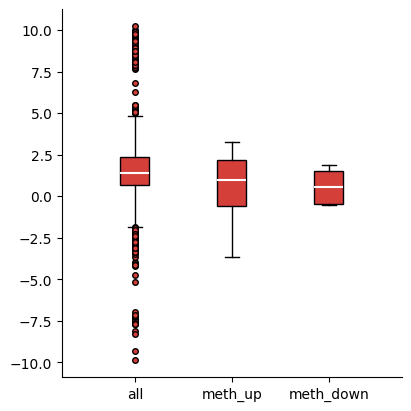

(None,)

In [151]:
scit.set_defaults(figsize=(4,4))
scit.pl.int.boxplot(
    [_rna['avg_log2FC'].to_numpy(), _rna.filter(pl.col('gene_name').is_in(meth_up))['avg_log2FC'].to_numpy(), _rna.filter(pl.col('gene_name').is_in(meth_down))['avg_log2FC'].to_numpy()],
    #[rna_change_my['score'].to_numpy(), rna_change_my.filter(pl.col('name').is_in(meth_up))['score'].to_numpy(), rna_change_my.filter(pl.col('name').is_in(meth_down))['score'].to_numpy()],
    ['all', 'meth_up', 'meth_down']
),

In [73]:
rna_change

pval,score,name,base_mean,group
f64,f64,str,f64,str
1.0,-0.055835,"""l(2)gl""",0.244264,"""Muscle somatic"""
1.0,0.0,"""CR11023""",0.0,"""Muscle somatic"""
1.0,-0.068216,"""spen""",1.533592,"""Muscle somatic"""
0.00009,0.519544,"""kis""",0.848222,"""Muscle somatic"""
0.003386,-1.159945,"""Cda5""",0.142047,"""Muscle somatic"""
…,…,…,…,…
1.0,0.0,"""lncRNA:CR45123""",0.0,"""Neuronal 2"""
1.0,0.0,"""Vml""",0.0,"""Neuronal 2"""
1.0,0.0,"""CG14422""",0.0,"""Neuronal 2"""


Muscle Muscle somatic
Meth_up: 763, Meth_down: 734


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


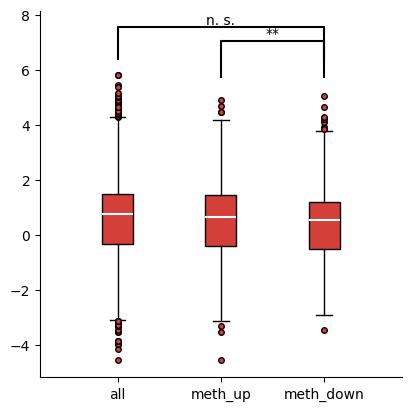

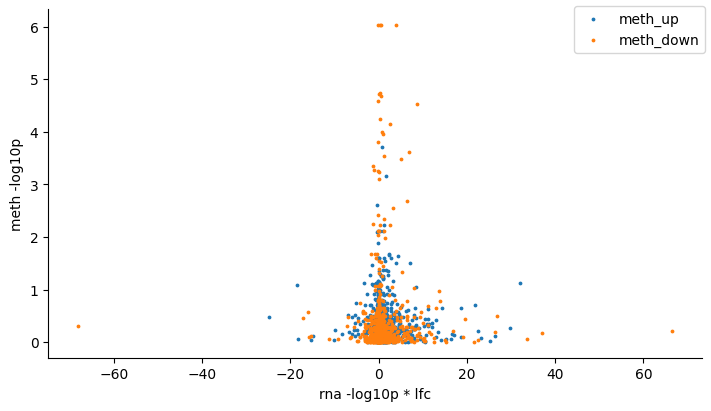

Muscle Muscle visceral
Meth_up: 618, Meth_down: 598


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


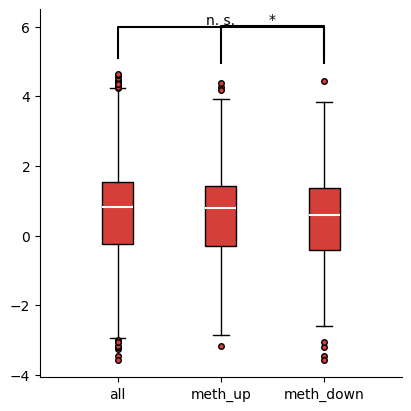

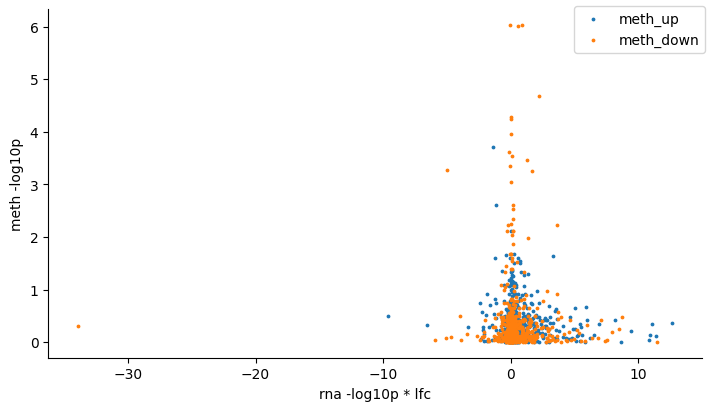

Fat Body Fat Body
Meth_up: 856, Meth_down: 912


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


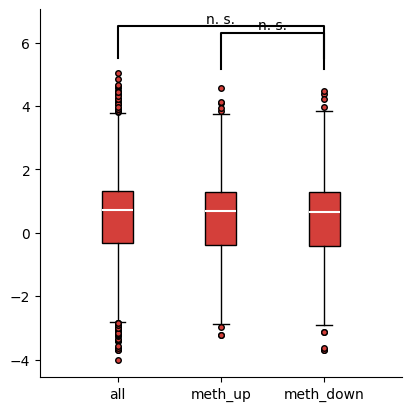

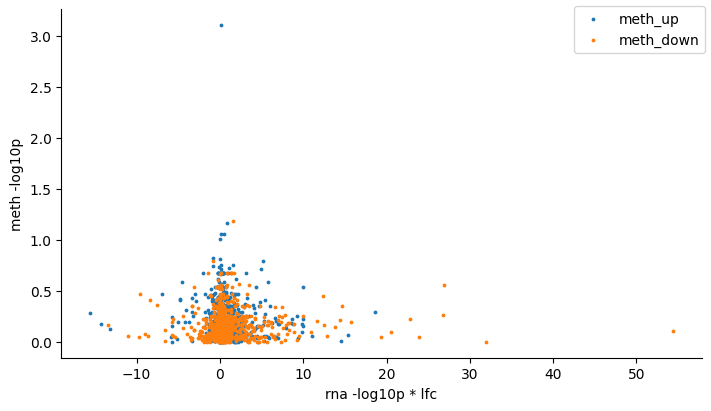

Epidermis Epidermis
Meth_up: 736, Meth_down: 816


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


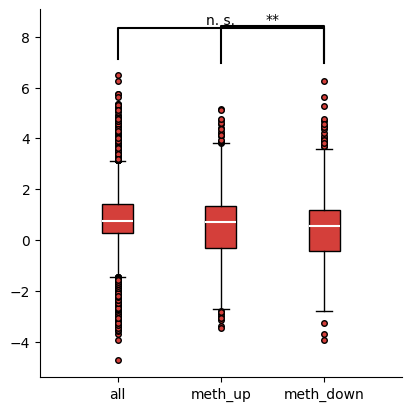

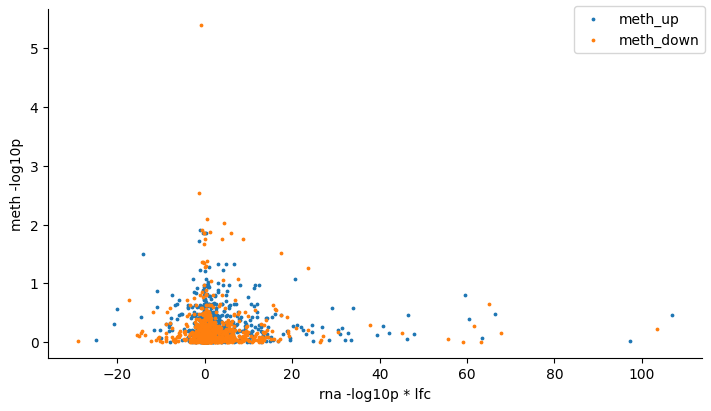

Midgut Midgut
Meth_up: 863, Meth_down: 913


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


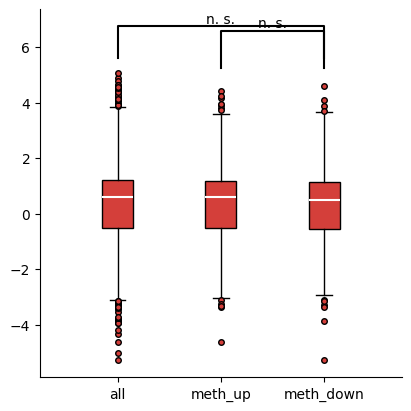

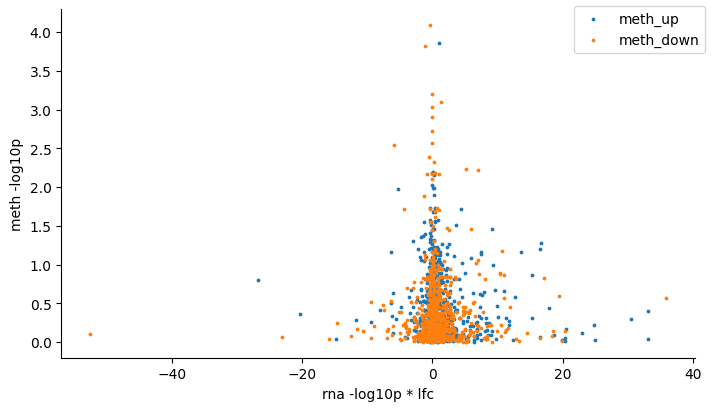

Ventral Nerve Cord Neuronal 1
Meth_up: 689, Meth_down: 703


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


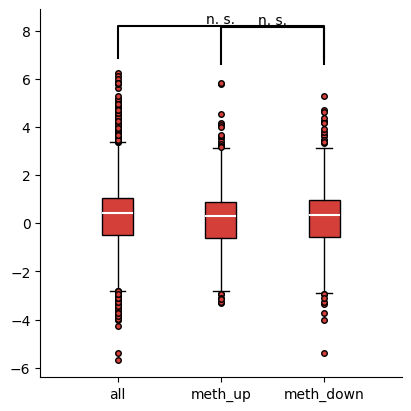

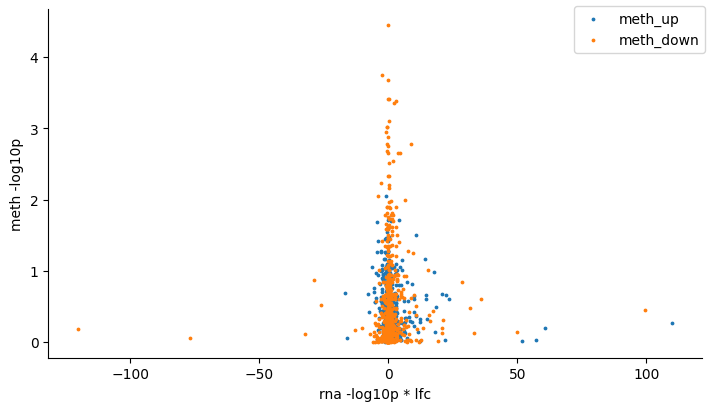

In [216]:
plots = [('Muscle', 'Muscle somatic'), ('Muscle', 'Muscle visceral'), ('Fat Body', 'Fat Body'), ('Epidermis', 'Epidermis'), ('Midgut', 'Midgut'), ('Ventral Nerve Cord', 'Neuronal 1')]
import matplotlib.pyplot as plt
RNA_PVAL_TH = 1

METH_BASE_MEAN = 0.5
METH_PVAL_TH = 1
SCORE_METH_TH = 0

for _cat in plots:
    print(_cat[0], _cat[1])
    rna_change_my = pl.read_csv('private/data/wt_mt_rna_change.csv')
    rna_change_my = rna_change_my.filter(pl.col('group')==_cat[1]).filter(pl.col('pval')<RNA_PVAL_TH)
    rna_change_my = rna_change_my.with_columns(
        np.log10(pl.col('pval')).neg().alias('ppval')
    ).with_columns(
        #(pl.col('ppval') * pl.col('score').sign()).alias('adj_score')
        (pl.col('ppval') * pl.col('score')).alias('adj_score')
    ).sort('adj_score')

    mt_muscle_meth = pl.read_csv('private/data/wt_mt_meth_change.csv').filter((pl.col('base_mean') > METH_BASE_MEAN) & (pl.col('group') == _cat[0]))
    mt_muscle_meth = mt_muscle_meth.filter(pl.col('pval')<METH_PVAL_TH)
    mt_muscle_meth = mt_muscle_meth.with_columns(
        np.log10(pl.col('pval')).neg().alias('ppval')
    ).with_columns(
        #(pl.col('ppval') * pl.col('score').sign()).alias('adj_score')
        (pl.col('ppval') * pl.col('score')).alias('adj_score')
    ).sort('adj_score')

    joint = mt_muscle_meth.join(rna_change_my, left_on='name', right_on='name', suffix='_rna')
    
    meth_up = joint.filter(pl.col('score') > SCORE_METH_TH)['name'].to_numpy()
    meth_down = joint.filter(pl.col('score') < -SCORE_METH_TH)['name'].to_numpy()
    print(f"Meth_up: {len(meth_up)}, Meth_down: {len(meth_down)}")
    scit.set_defaults(figsize=(4,4))
    up_in = rna_change_my.filter(pl.col('name').is_in(meth_up))['score'].to_numpy()
    down_in = rna_change_my.filter(pl.col('name').is_in(meth_down))['score'].to_numpy()
    if len(up_in) == 0:
        up_in = [0]
    if len(down_in) == 0:
        down_in = [0]
    stat = None
    if len(up_in) > 1 and len(down_in) > 1:
        stat = scit.tl.statistic_test([[], up_in, down_in], [(0,2), (1,2)], test_type='mannwhitneyu')
    scit.pl.int.boxplot(
        [rna_change_my['score'].to_numpy(), up_in, down_in],
        ['all', 'meth_up', 'meth_down'], stat=stat
    )
    scit.set_defaults(figsize=(7,4))
    f=scit.pl.int.scatter(
        [
            np.c_[(joint.filter(pl.col('score')>0)['adj_score_rna']), joint.filter(pl.col('score')>0)['ppval'].to_numpy()],
            np.c_[(joint.filter(pl.col('score')<0)['adj_score_rna']), joint.filter(pl.col('score')<0)['ppval'].to_numpy()],
        ],
        ['meth_up', 'meth_down'],
        show=False
    )
    f.axes[0].set_ylabel('meth -log10p')
    f.axes[0].set_xlabel('rna -log10p * lfc')
    plt.show()

In [1]:
scit.set_defaults(figsize=(6,4))
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

scit.tl.layer_pick_features(cttag, lc_meth, 'RecQ5')
scit.tl.copy_to_obs(cttag, lc_meth)
scit.pl.embedding2d(cttag, 'X_umap', 'copied_data', cmap='Reds')

scit.tl.layer_pick_features(mt, lc_meth, 'RecQ5')
scit.tl.copy_to_obs(mt, lc_meth)
scit.pl.embedding2d(mt, 'X_umap', 'copied_data', cmap='Reds')

NameError: name 'scit' is not defined